# Introduction — GRU Forecasting and Research Motivation

The motivation for this research is based on the Efficient Market Hypothesis **[1, Efficient Market Hypothesis: Basics and Forms, 2024]**, which explains how information is reflected in stock prices. The weak form of EMH states that historical trading information such as past prices, returns, and trading volume is already incorporated into current market prices **[1, Efficient Market Hypothesis: Basics and Forms, 2024]**. This implies that models relying only on historical price data should have limited predictive power.

To examine this idea, we first build a baseline model that uses only past returns. If this model performs poorly, it provides empirical support for weak-form market efficiency. The semi-strong form of EMH suggests that all publicly available information - including news sentiment, macroeconomic states, and abnormal market behaviour - is also reflected in stock prices **[1, Efficient Market Hypothesis: Basics and Forms, 2024]**. 

Therefore, this research investigates whether incorporating such additional information can improve forecasting performance beyond what can be achieved using historical prices alone.

To test this, we use a **Gated Recurrent Unit (GRU)** deep learning model that can capture non-linear relationships and temporal dependencies in financial time series. Unlike traditional statistical models, **GRU** can process multiple data sources simultaneously and learn complex interactions between them.

In this research the GRU model is trained using multi-modal financial data, including:
- **Technical price information** - Open, high, low prices and trading volume.
- **Sentiment indicators** - dDaily sentiment labels.
- **Macroeconomic states** - Recession versus non-recession conditions.
- **Anomaly detection signals** - Persistent abnormal market behaviour.
- **Target variable** - Daily stock returns, calculated as percentage change in closing prices.

Using returns as the prediction target helps stabilise the series and allows the model to focus on meaningful price movements rather than long-term trends.

The choice of GRU instead of LSTM is supported by prior research showing that GRU can achieve lower RMSE and MAE and slightly higher Directional Accuracy while maintaining a simpler structure and faster training **[2, Advancements in Stock Price Prediction: Integrating Statistical, Machine Learning, and Deep Learning Models, 2025, p.9]**. Additionaly GRU models often demonstrate a wider range of lower RMSE values across time-series forecasting tasks, indicating strong predictive capability and computational efficiency **[3, Long Short-Term Memory vs Gated Recurrent Unit: A Literature Review on the Performance of Deep Learning Methods in Temperature Time Series Forecasting, 2024, p.1506]**. Furthermore, Directional Accuracy is an important evaluation metric because correctly predicting the direction of returns is highly relevant for trading and risk management decisions **[2, Advancements in Stock Price Prediction: Integrating Statistical, Machine Learning, and Deep Learning Models, 2025, p.9]**.

To evaluate whether the GRU model provides meaningful improvements, we compare it with a baseline ARIMA model. ARIMA is widely used as a benchmark in financial forecasting because it captures linear temporal structure using only historical observations **[2, Advancements in Stock Price Prediction: Integrating Statistical, Machine Learning, and Deep Learning Models, 2025, p.2]**. In this study, ARIMA is trained using only past return values, making it consistent with the weak-form EMH assumption and providing a clear reference point for measuring the additional predictive value of sentiment, macroeconomic, and anomaly detection information **[1, Efficient Market Hypothesis: Basics and Forms, 2024]**.

Overall, this experimental design allows us to examine whether using additional publicly available information through for GRU model can improve return prediction and directional accuracy compared to a traditional ARIMA baseline, providing practical insight into weak and semi-strong market efficiency **[1, Efficient Market Hypothesis: Basics and Forms, 2024]**.

> **References:**  
> \[1\] EBC Financial Group, “Efficient Market Hypothesis: Basics and Forms,” 2024-12-19. [Online]. Available: [www.ebc.com](https://www.ebc.com/forex/efficient-market-hypothesis-basics-and-forms)
> 
> \[2\] D. N. Kalange, “Advancements in Stock Price Prediction: Integrating Statistical, Machine Learning, and Deep Learning Models,” International Journal on Science and Technology (IJSAT), vol. 16, no. 3, pp. 1–11, Jul.–Sep. 2025, E-ISSN: 2229-7677. [Online]. Available: [www.ijsat.org](https://www.ijsat.org/papers/2025/3/7103.pdf)
>
> \[3\]  F. Furizal, A. B. Fawait, H. Maghfiroh, A. Ma’arif, A. A. F. Firdaus, and I. Suwarno, “Long Short-Term Memory vs Gated Recurrent Unit: A Literature Review on the Performance of Deep Learning Methods in Temperature Time Series Forecasting,” International Journal of Robotics and Control Systems, vol. 4, no. 3, pp. 1506–1526, Sep. 2024, ISSN 2775-2658. [Online]. Available: [www.researchgate.net](https://www.researchgate.net/publication/384235147_Long_Short-Term_Memory_vs_Gated_Recurrent_Unit_A_Literature_Review_on_the_Performance_of_Deep_Learning_Methods_in_Temperature_Time_Series_Forecasting) 

---

# Evaluation Methodology

The **GRU forecasts** for the **Return series** will be evaluated using the same standard **time-series prediction metrics** that were used for the **ARIMA model evaluation**: **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Error (MAE)**, along with **Directional Accuracy** and **Correlation**. For **MSE**, **RMSE**, **and MAE**, only **returns above a certain threshold** will be considered to focus on **meaningful price movements**. This threshold will be the **same as the one used when creating MSE**, **RMSE**, **and MAE for the ARIMA model**, ensuring a fair comparison. 

After collecting the **evaluation metrics** for all GRU models, we will identify which **feature combinations** outperform the **ARIMA model**. The results of these models will be stored in a separate **DataFrame** for further analysis.

Next, we will calculate an **Improvement Score** to create a **single value** that indicates how much better each **GRU model** performs compared to the **ARIMA model**. Only models that outperform ARIMA on **at least two metrics** will receive a score. The **GRU models** will then be **ranked** based on this **Improvement Score** to identify the **best-performing models**.

Finally, we will build **graphs** for **MSE**, **RMSE**, **MAE**, **Directional Accuracy**, **Correlation**, **and Improvement Score** to visually compare **GRU vs ARIMA performance**. The **visualizations** will highlight which **feature combinations** and **datasets** lead to the **most accurate forecasts**, making it easier to **interpret and communicate the results**.

---

**Metric Descriptions**

**Mean Squared Error (MSE) Description**:<br>
Calculates the average of the squared differences between predicted and actual values. It penalizes larger errors more heavily and indicates how closely the predictions match the actual series. The formula for MSE is shown below:

- **MSE** = $\Large \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

**Root Mean Squared Error (RMSE) Description**:<br>
Calculates the square root of MSE, which brings the error back to the original scale of the series. It provides a measure of average prediction error in the same units as the data:

- **RMSE** = $\Large \sqrt{MSE}$

**Mean Absolute Error (MAE) Description**:<br>
Calculates the average of the absolute differences between predicted and actual values. It measures the average magnitude of prediction errors regardless of direction:

- **MAE** = $\Large \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

**Directional Accuracy Description**:<br>
Measures how often the predicted direction of change matches the actual direction. This is useful in financial applications where predicting upward or downward movements correctly is important:

- **Directional Accuracy** = $\Large \frac{\text{Number of correct directions}}{\text{Total predictions}}$

**Correlation Description**:<br>
Calculates the Pearson correlation coefficient between predicted and actual values. It indicates how closely the predicted series follows the actual series in terms of overall trend and pattern:

- **Correlation** = $\Large \frac{\text{Cov}(y, \hat{y})}{\sigma_y \sigma_{\hat{y}}}$

**Improvement Score Description**:<br>
Calculates how much better a GRU model performs compared to the ARIMA baseline across multiple metrics. It combines relative improvements in MSE, RMSE, MAE, and Directional Accuracy into a single value. Only models that outperform ARIMA on at least two metrics receive a non-zero score. A higher score indicates greater overall improvement over the baseline:

**Improvement Score** = $\Large \frac{(\text{ARIMA}_\text{MSE} - \text{GRU}_\text{MSE})}{\text{ARIMA}_\text{MSE}} + \frac{(\text{ARIMA}_\text{RMSE} - \text{GRU}_\text{RMSE})}{\text{ARIMA}_\text{RMSE}} + \frac{(\text{ARIMA}_\text{MAE} - \text{GRU}_\text{MAE})}{\text{ARIMA}_\text{MAE}} + \frac{(\text{GRU}_\text{DA} - \text{ARIMA}_\text{DA})}{\text{ARIMA}_\text{DA}}$

---

# Methodology

1. **Data Loading and Preparation**
    - Load the CSV file containing **daily stock prices**, **sentiment indicators**, **anomaly signals**, and **macroeconomic states**.
    - Prepare the key series for forecasting:
        - **Return series** - calculated as the daily percentage change of closing prices.
    - Convert categorical data into numeric format:
        - **Sentiment analysis labels** into numeric values.
        - **Macroeconomic states** into binary values.
    - Organize features into four groups and systematically evaluate **all combinations** for each dataset.
    <br>           

2. **Feature Scaling and Sequence Creation**
    - Split the dataset into **train and test sets** using **80/20 ratio**.
    - Scale input features using **MinMax scaling** based on training data and apply the same scaling to test data.
    - Create input sequences using a **rolling window approach**:
        - **Lookback period**: 30 days.
        - Each sequence contains **historical feature values**.
        - The target value is the **return immediately after the sequence**.
    - Convert sequences and targets to **PyTorch tensors** for model input.
    - Ensure **reproducibility** by setting fixed **random seeds** for Python, NumPy, and PyTorch, and using **deterministic GPU operations**.
    <br> 
          
3. **Feature Group Experiments**
    - Train and evaluate GRU models for **all possible combinations of feature groups**:
        - Single feature groups.
        - Pairwise combinations.
        - Larger combinations up to **all four groups**.
    - This allows analysis of which **feature combinations** improve forecasting performance.
    <br> 
          
4. **GRU Model Construction**
    - Implement a **Gated Recurrent Unit (GRU)** neural network for return forecasting.
    - The model consists of:
        - **2 stacked GRU layers**.
        - **64 hidden units** per layer.
        - **Fully connected layer** to map GRU output to a single prediction.
    - Use the **final time step output** of the GRU to generate the forecast.
    <br> 
          
5. **Model Training**
    - Train the GRU model using:
        - **Mean Squared Error (MSE)** as the loss function.
        - **Adam optimizer**.
    - Train for a fixed number of **epochs**.
    - Use mini-batch training without shuffling to preserve temporal order.
    - Repeat the training process for different feature group combinations and datasets.
    <br>
   
6. **Evaluation and Visualization**
    - Generate predictions on the test set.
    - Calculate evaluation metrics:
        - Mean Squared Error (MSE)
        - Root Mean Squared Error (RMSE)
        - Mean Absolute Error (MAE)
        - Directional Accuracy
        - Correlation between predicted and actual returns
        - Improvement score – measures how much the GRU model outperforms ARIMA baseline across multiple metrics.
    - Apply a return threshold when calculating error metrics to focus on significant movements.
    - Compare GRU results with the ARIMA baseline.
    - Record all results in a summary table for analysis.
    - Visualize results using line plots and bar charts for better interpretation.
    <br>

---

# 2. GRU Model Implementation

This section is responsible for **defining the functions** required for **GRU model creation**, **training**, **testing**, and **data collection** for further **performance comparison** with the **ARIMA baseline model**.

## 2.1 Install Dependencies

Uncomment and run the code in the next cell to install the required dependencies for this notebook.

In [1]:
#!pip install pandas matplotlib scikit-learn torch

## 2.2 Import Deendencies

In [2]:
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from itertools import combinations

## 2.3 Setup reproducibility

The code in the next cell ensures that the notebook results can be reproduced. It sets fixed random seeds for **random**, **NumPy**, and **PyTorch**, and enforces deterministic operations in PyTorch to reduce variation from GPU computations. This ensures that the same results are produced every time the notebook is run.

In [3]:
# Create seed to ensure reproducibility
seed = 2014

# Set random seed to created seed
random.seed(seed)

# Set numpy random seed to created seed
np.random.seed(seed)

# Set pytorch CPU seed to created seed
torch.manual_seed(seed)

# Set pytorch GPU seeds to created seed
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Set pytorch deterministic to true
torch.backends.cudnn.deterministic = True

# Set pytorch benchmark to false
torch.backends.cudnn.benchmark = False

# Set pytorch to use deterministic algorithms
torch.use_deterministic_algorithms(True)

## 2.4 Load and Prepare Dataset for GRU Training

**load_dataset()** - Loads a CSV dataset and prepares it for GRU model training:
- **Reads the CSV file** and parses the "date" column as datetime.
- **Sorts the data** by date in ascending order and resets the index.
- **Calculates daily returns** as the percentage change of the "close" price.
- **Converts sentiment labels** into numeric values:
    - The string value "positive" is converted to 2
    - The string value "neutral" is converted to 1
    - The string value "no_news" is converted to 0
    - The string value "negative" is converted to -1
- **Converts economic state labels** into numeric values:
    - The string value "Recession" is converted to 1
    - The string value "Not_Recession" is converted to 0
- **Returns the processed DataFrame** ready for GRU model training.

In [4]:
# Function to load dataset from CSV file and prepare data
def load_dataset(file_name):
    # Load passed csv file
    df = pd.read_csv(file_name, parse_dates=["date"])

    # Sort DataFrame by dates in ascending order
    df.sort_values("date", ascending = True, inplace = True)
    # Reset index after sorting to ensure consistency
    df.reset_index(drop = True, inplace = True)

    # Calculate daily % returns using: ((close_t - close_{t-1} / close_{t-1})
    df['return'] = df['close'].pct_change().fillna(0)

    # Convert string sentiment labels into numeric values
    df["daily_sentiment"] = df["daily_sentiment"].map({
        "positive": 2,
        "neutral": 1,
        "no_news": 0,
        "negative": -1
    }).fillna(0)

    # Convert string recession labels into numeric values
    df["economic_state"] = df["economic_state"].map({
        "Recession": 1,
        "Not_Recession": 0
    }).fillna(0)

    return df

## 2.5 Prepare Time Series Data for GRU Training

**TimeSeriesDataset()** - Creates a dataset object and prepares time series data for GRU model training:
- **Initializes the dataset** by converting feature sequences into PyTorch FloatTensor.
- **Initializes the target values** by converting them into PyTorch FloatTensor.
- **Returns the dataset length** representing the total number of sequences.
- **Retrieves a sequence and its corresponding target** for a given index, ready for use in a PyTorch DataLoader during training.

In [5]:
# Class that allows us to preprate data for GRU training
class TimeSeriesDataset(Dataset):
    def __init__(self, features, target):
        # Convert feature sequences to FloatTensor
        self.features = torch.FloatTensor(features)
        
        # Convert target values to FloatTensor
        self.target = torch.FloatTensor(target)

    def __len__(self):
        # Return total number of feature sequences
        return len(self.features)

    def __getitem__(self, index):
        # Return feature sequence and corresponding target value at given index
        return self.features[index], self.target[index]

## 2.6 Define GRU Model for Time Series Prediction

**GRUModel()** - Creates a GRU model for time series prediction:
- **Initializes the GRU layer** with the specified number of input features, hidden units, and stacked layers.
- **Sets batch_first** to True so that input shape is (batch, sequence, features).
- **Initializes a fully connected layer** to convert the last GRU output into a single prediction.
- **Processes input sequences** through the GRU layer during the forward pass.
- **Selects the output from the last time step** of each sequence as a summary representation.
- **Passes the summary through the fully connected layer** to produce predictions.
- **Removes extra dimensions** so that predictions match the target shape.

In [6]:
# Class to create and use GRU model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        # Create GRU layer
        # input_size = number of features
        # hidden_size = number of neurons in hidden layer
        # num_layers = number of stacked GRU layers
        # batch_first = True means input shape is (batch, sequence, features)
        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True
        )

        # Create fully connected layer to convert GRU output to single prediction
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, batch_sequences):
        # Pass input sequences through GRU layer
        gru_outputs, _ = self.gru(batch_sequences)   
        
        # Select output from last time step of each sequence
        sequence_summary = gru_outputs[:, -1, :]          
        
        # Pass last hidden state through fully connected layer
        predictions = self.fc(sequence_summary)
        
        # Remove extra dimension to match target shape
        predictions_to_return = predictions.squeeze()
        
        return predictions_to_return

## 2.7 Select Device (CPU or GPU) for Training

**get_device()** - Selects the computational device for GRU model training:
- **Sets the default device** to CPU.
- **Checks if a GPU is available** and switches the device to GPU if true.
- **Prints the selected device** to inform the user.
- **Returns the device** to be used for model training and evaluation.

In [7]:
# Function to create computational device and assign it to CPU or GPU if it is available
def get_device():
    # Create computational device and assign it to CPU by default
    device = "cpu"

    # Verify that GPU is available and assign the device to it if true
    if torch.cuda.is_available():
        device = "cuda"
        
    print("Device is set to:", device)
    
    return device

## 2.8 Split Time Series Data into Train and Test Sets

**split_timeseries()** - Splits a time series DataFrame into training and testing sets:
- **Calculates the split index** based on the specified train-test ratio.
- **Creates the training DataFrame** using data up to the split index.
- **Creates the testing DataFrame** using data after the split index.
- **Returns the training and testing DataFrames** ready for scaling and sequence creation.

In [8]:
# Function to split series into train and test datasets
def split_timeseries(df, split_ratio):
    # Find position where DataFrame should be split into train and test DataFrames
    split_index = int(len(df) * split_ratio)

    # Create train DataFrame
    train_df = df[:split_index].copy() 
    # Create test DataFrame
    test_df = df[split_index:].copy() 
    
    return train_df, test_df

## 2.9 Scale Features Using Min-Max Scaler

**scale_features()** - Scales feature values in training and testing datasets for GRU model training:
- **Initializes a Min-Max scaler** to normalize feature values between 0 and 1.
- **Fits the scaler on the training DataFrame** and transforms the training features.
- **Applies the same scaling parameters to the testing DataFrame** to ensure consistency.
- **Returns the scaled training and testing feature arrays** ready for sequence creation.

In [9]:
# Function to scale series data
def scale_features(train_df, test_df, features):
    # Create scaler
    min_max_scaler = MinMaxScaler()

    # Learn min and max values from train DataFrame and then apply them to it for scaling
    scaled_train_df = min_max_scaler.fit_transform(train_df[features].values)

    # Apply learnt min and max values to test DataFrame for scaling
    scaled_test_df  = min_max_scaler.transform(test_df[features].values)

    return scaled_train_df, scaled_test_df

## 2.10 Create Input Sequences for GRU Training

**create_sequences()** - Generates input sequences and corresponding targets for GRU model training:
- **Calculates the number of sequences** that can be created based on the specified lookback period.
- **Iterates over the feature data** to create sequences of the specified length.
- **Collects the target values** that follow each feature sequence.
- **Converts the feature and target lists into NumPy arrays** suitable for GRU training.
- **Returns the feature sequences and target sequences** ready for DataLoader creation.

In [10]:
# Function to create seqeuences for GRU model training.
def create_sequences(features, target, lookback):
    # Create empty lists for feature and target sequences
    features_sequences, target_sequences = [], []

    # Calculate how many sequences we can create
    iteration_length = len(features) - lookback

    # Loop over the data "iteration_length" times to create sequences
    for i in range(iteration_length):
        # Add a sequence of 'lookback' features to the list
        features_sequences.append(features[i : i + lookback])
        # Add the target value after this sequence
        target_sequences.append(target[i + lookback])

    # Convert lists to NP arrays
    features_sequences_np_array = np.array(features_sequences)
    target_sequences_np_array = np.array(target_sequences)
    
    return features_sequences_np_array, target_sequences_np_array

## 2.11 Create DataLoaders for Training and Testing

**build_loaders()** - Creates PyTorch DataLoaders for batching GRU training and testing data:
- **Wraps the feature and target sequences** into TimeSeriesDataset objects for training and testing.
- **Creates the training DataLoader** using the specified batch size without shuffling.
- **Creates the testing DataLoader** using the specified batch size without shuffling.
- **Returns the training and testing DataLoaders** ready for model training and evaluation.

In [11]:
# Function to create DataLoaders for GRU model training and testing
def build_loaders(train_feature_sequences, 
                  train_target_sequences, 
                  test_feature_sequences, 
                  test_target_sequences, 
                  batch_size):

    # Create training object with train feature and test sequences using passed batch size
    train_loader = DataLoader(TimeSeriesDataset(train_feature_sequences, train_target_sequences), 
                              batch_size = batch_size, 
                              shuffle = False)

    # Create test object with test feature and test sequences using passed batch size
    test_loader = DataLoader(TimeSeriesDataset(test_feature_sequences, test_target_sequences), 
                             batch_size = batch_size, 
                             shuffle = False)

    return train_loader, test_loader

## 2.12 Train GRU Model on Time Series Data

**train_model()** - Trains the GRU model using the provided DataLoader:
- **Defines the loss function** as Mean Squared Error (MSE).
- **Creates the optimizer** using the Adam algorithm with the specified learning rate.
- **Sets the model to training mode** to enable gradient computation.
- **Iterates over the specified number of epochs**, and for each epoch:
    - **Moves feature and target sequences to the computational device** (CPU or GPU).
    - **Generates predictions** from the model using the feature sequences.
    - **Calculates the loss** between predictions and actual targets.
    - **Clears previous gradients** and performs backpropagation to compute new gradients.
    - **Updates model weights** using the optimizer.
- **Returns the trained model** ready for evaluation.

In [12]:
# Function to train GRU model
def train_model(model, 
                loader, 
                device, 
                epochs, 
                learning_rate):

    # Create function to calculate loss
    loss_function = nn.MSELoss()

    # Create optimizer using Adam
    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    # Set model to train state
    model.train()

    # Iterate epochs number of times to train the model
    for _ in range(epochs):
        # Iterate over loader object
        for feature_sequences, target_sequences in loader:
            # Pass feature sequence to computational device(CPU or GPU)
            feature_sequences = feature_sequences.to(device)
            
            # Pass target sequence to computational device(CPU or GPU)
            target_sequences = target_sequences.to(device)

            # Create predictions using model and feature sequences
            predictions = model(feature_sequences)
            
            # Calculate loss using loss_function with created predictions and real target data
            loss = loss_function(predictions, target_sequences)

            # Clear old gradients
            optimizer.zero_grad()

            # Calculate new gradients using backpropagation
            loss.backward()

            # Update model weights
            optimizer.step()

    return model

## 2.13 Evaluate GRU Model and Get Predictions

**evaluate_model()** - Evaluates a trained GRU model and returns predictions alongside actual target values:
- **Sets the model to evaluation mode** to disable gradient computation.
- **Initializes empty lists** to store predictions and actual values.
- **Iterates over the batches** in the DataLoader:
- **Moves feature sequences to the computational device** (CPU or GPU).
- **Generates predictions** from the model for the current batch.
- **Saves predictions and actual target values** to the respective lists.
- **Converts the predictions and actual values lists into flattened NumPy arrays**.
- **Returns the predictions and actual values** for further evaluation or metric calculation.

In [13]:
# Function to evaluate trained GRU model and extract predictions
def evaluate_model(model, loader, device):
    # Set model to evaluation state
    model.eval()

    predictions = []
    actual_data = []

    with torch.no_grad():
        # Iterate over batches from loader object
        for features, target in loader:
            # Move features to the computational device(CPU or GPU)
            features = features.to(device)
            # Create predictions for the current batch
            current_predictions = model(features)

            # Save current predictions
            predictions.extend(current_predictions.cpu().numpy())
            # Save current actual data
            actual_data.extend(target.numpy())

    # Cast predictions list to NP flatten array
    predictions_to_return = np.array(predictions).flatten()
    # Cast actual_data list to NP flatten array
    actual_data_to_return = np.array(actual_data).flatten()

    
    return predictions_to_return,  actual_data_to_return

## 2.14 Compute Evaluation Metrics for Predictions 

**calculate_evaluation_metrics()** - Calculates evaluation metrics for GRU model predictions compared to actual values:
- **Checks if a threshold is provided**; if not, prints a message and returns nothing.
- **Filters predictions and actual values** that are above the specified threshold:
If no values are above the threshold, **MSE**, **RMSE**, **and MAE are set to None**.
Otherwise, **calculates MSE**, **RMSE**, **and MAE** for the filtered data.
- **Calculates directional accuracy** as the proportion of predictions that have the same sign as the actual values.
- **Calculates correlation** between predictions and actual values if there are at least two data points; otherwise, sets correlation to None.
- **Returns all metrics**: MSE, RMSE, MAE, directional accuracy, and correlation.

In [14]:
# Function to calculate evaluation metrics including:
    # MSE
    # RMSE
    # MAE
    # Directional Accuracy
    # Correlation
def calculate_evaluation_metrics(predictions, actual, threshold):
    # Verify that threshold was provided.
    # If not then print message and return nothing.
    if threshold is None:
        print("No threshold")
        return None, None, None, None, None

    # Create a boolean mask of actual values that are above threshold
    mask = np.abs(actual) > threshold

    # Verify that mask is longer than 1 otherwise assign None to MSE, RMSE, and MAE
    if np.sum(mask) < 1:
        mse = None
        rmse = None
        mae = None
    else:
        # Create a list of filtered predictions that are above threshold
        filtered_predictions = predictions[mask]
        # Create a list of filtered actual values that are above threshold
        filtered_actual = actual[mask]

        # Calculate MSE, RMSE, and MAE
        mse = np.mean((filtered_predictions - filtered_actual) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(filtered_predictions - filtered_actual))

    # Calculate directional accuracy
    directional_accuracy = np.mean(np.sign(predictions) == np.sign(actual))

    # Verify that predictions are longer than 2 otherwise return None for correlation
    if len(predictions) < 2:
        correlation = None
    else:
        correlation = np.corrcoef(predictions, actual)[0, 1]

    return mse, rmse, mae, directional_accuracy, correlation


# 2.15 Run GRU Experiment 

**run_experiment()** - Runs the full GRU workflow from data preparation to model evaluation:
- **Splits the DataFrame** into training and testing sets using a specified ratio (default 80%/20%).
- **Scales feature values** in both training and testing sets using Min-Max scaling.
- **Extracts target values** from the training and testing DataFrames.
- **Creates sequences** of features and corresponding target values for GRU training using the specified lookback window.
- **Builds DataLoaders** for training and testing sequences with a defined batch size.
- **Initializes the GRU model** with specified input size, hidden size, and number of layers, and moves it to the computational device.
- **Trains the GRU model** using the training DataLoader, defined number of epochs, and learning rate.
- **Evaluates the trained model** on the test DataLoader to get predictions and actual target values.
- **Calculates evaluation metrics** (MSE, RMSE, MAE, directional accuracy, and correlation) using a specified threshold.
- **Returns a dictionary** containing all metrics, predictions, and actual values for further analysis or plotting.
  
**Parameters used for the experiments**:
- **Hidden size = 64** - Provides a good balance between model complexity and size.
- **Number of layers = 2** - Allows the GRU model to learn detailed temporal patterns without becoming unnecessarily deep.
- **Batch size = 64** - Provides a good balance between training speed and stability, keeping training stable and reasonably fast.
- **Epochs = 200** - Gives the GRU model enough time to learn from the data.
- **Learning rate = 0.001** - Enables slow and stable learning while reducing the risk of overfitting.
- **Threshold = 0.07** - Uses the same threshold as the ARIMA model to ensure a fair comparison.

In [15]:
def run_experiment(df, features, target, lookback, device):
    # Split DataFrame into train and test DataFrames using 80%/20% ratio.
    # Change split_ratio to increase or decrease train/test DataFrames
    train_df, test_df = split_timeseries(df, split_ratio = 0.8)

    # Scale values in train and test DataFrames using only features that are currently used for training/evaluation
    train_df_scaled, test_df_scaled = scale_features(train_df, test_df, features)

    # Create train target df
    train_targets_df = train_df[target].values
    # Create test target df
    test_targets_df  = test_df[target].values

    # Create train and test sequences for features and targets
    train_feature_sequences, train_target_sequences = create_sequences(train_df_scaled, train_targets_df, lookback)
    test_feature_sequences,  test_target_sequences  = create_sequences(test_df_scaled,  test_targets_df,  lookback)

    # Create train and test DataLoaders for batching the sequences
    train_loader, test_loader = build_loaders(
                                                train_feature_sequences = train_feature_sequences, 
                                                train_target_sequences = train_target_sequences, 
                                                test_feature_sequences = test_feature_sequences, 
                                                test_target_sequences = test_target_sequences,
                                                batch_size = 64
                                             )
 
    # Call "GRUModel" function to create GRU model and move to computational device
    model = GRUModel(
                        input_size = len(features),
                        hidden_size = 64,
                        num_layers = 2
                    ).to(device)

    # Call "train_model" function to train the model
    model = train_model(
                            model, 
                            train_loader, 
                            device,
                            epochs = 200, 
                            learning_rate = 0.001
                        )

    # Call "evaluate_model" to create data for evaluation
    predictions, actual_data = evaluate_model(model, test_loader, device)

    # Threshould for MSE, RMSE, MAE metrics calcualtion.
    # It must be the same as the threshould for metrics calculation used for ARIMA model
    threshold = 0.07
    
    # Call "calculate_evaluation_metrics" function to generate evaluation metrics 
    mse, rmse, mae, directional_accuracy, correlation = calculate_evaluation_metrics(predictions, actual_data, threshold)

    # Return both metrics AND predictions
    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "directional_accuracy": directional_accuracy,
        "correlation": correlation, 
        "predictions": predictions,
        "actual": actual_data
    }


## 2.16 Load Datasets for GRU Model Training and Testing

The next cell loads multiple CSV datasets and prepares them for GRU model training and testing:
- **Defines paths** to all datasets that need to be loaded.
- **Creates a dictionary** to store dataset names and their corresponding DataFrames.
- **Iterates over the datasets**, loading each CSV using **load_dataset()** function
- **Stores the processed DataFrames** in a dictionary for later use in training and evaluation.

In [16]:
# Create paths to datasets
datasets = {
    "Official": "./Datasets/td_sa_official_recessions_with_anomalies.csv",
    "Predictions": "./Datasets/td_sa_predicted_recessions_with_anomalies.csv"
}

# Dictionary to hold dataset names and DataFrames
dataframes = {}

# Iterate over datasets and load each dataset in a DataFrame
for dataframe_name, file_path in datasets.items():
    dataframes[dataframe_name] = load_dataset(file_path)

## 2.17 Define Features and Target

The next cell specifies which columns from the dataset will be used as input features and which column will be used as a target. The features are also split into different groups:
- **Price features** - Include **open**, **high**, **low**, and **volume** to capture market price movements.
- **Sentiment features** - Include **daily_sentiment** and **weighted_sentiment_rolling_z_score** to capture market sentiment signals.
- **Macro features** - Include **economic_state** to reflect the economic environment.
- **Anomaly features** - Include **anomaly_persistent** to account for unusual events in the data.
- **Target variable** - Include **return**, representing the value the GRU model will predict.

In [17]:
price_features = ["open", "high", "low", "volume"]

sentiment_features = [
    "daily_sentiment",
    "weighted_sentiment_rolling_z_score"
]

macro_features = ["economic_state"]

anomaly_features = ["anomaly_persistent"]

target = "return"

## 2.18 Create computational device

The next cell creates a computational device that will be used for GRU model training and evaluation. It assigns the device to GPU if available, otherwise defaults to CPU. The created device is stored in the variable **device**.

In [18]:
device = get_device()

Device is set to: cuda


## 2.19 Run Experiments for All Feature Combinations

The next cell runs GRU model experiments using all possible combinations of feature groups for each dataset. It iterates over the datasets and feature group combinations to train, evaluate, and save results:
- **Feature groups** - Define groups of input features: price, sentiment, macro, and anomaly.
- **All feature combinations** - Generate all possible combinations of feature groups, from single groups to all groups combined.
- **Iterate over datasets** - For each dataset, the GRU model is trained and evaluated for every feature combination.
- **Experiment naming** - Each experiment is named based on the dataset and the feature combination used.
- **Model training and evaluation** - Calls the **run_experiment()** function with the current dataset, selected features, target variable, lookback period, and computational device.
- **Store results** - Evaluation metrics and predictions for each experiment are saved in a dictionary for later analysis and comparison.

**Parameters used in this experiment**:
- **Lookback = 30** - Provides the GRU model with the previous 30 days of data to make the next prediction.
- **Target = return** - The GRU model predicts the stationary **return** series, the same target used in the ARIMA baseline for fair comparison. More details are provided in the ARIMA Baseline module.
- **Device = device** - Uses the available computational device (CPU or GPU) to speed up training and evaluation when CUDA is available.

In [19]:
# Dictionary for feature groups for GRU model training and evaluation
feature_groups = {
    "price": price_features,
    "sentiment": sentiment_features,
    "macro": macro_features,
    "anomaly": anomaly_features
}

# Dictionary to hold all the results
all_results = {}

# Create list of feature group names
group_names = list(feature_groups.keys())

# Calcualte the total number of datasets used for GRU model training and evaluation
total_datasets = len(dataframes)

# Iterate over each dataset 
for dataset_index, (dataset_name, df) in enumerate(dataframes.items(), start=1):

    # Print name of the current Dataset used for GRU model training and evaluation
    print("------------------------------------------------------------------------------------------------------")
    print(f"DATASET: {dataset_name}. {dataset_index}/{total_datasets}")
    print("------------------------------------------------------------------------------------------------------")

    # Dictionary to save results for the currently used dataset
    current_results = {}

    # Generate combinations of feature groups
    all_combinations = []
    for group_size in range(1, len(group_names) + 1):
        all_combinations.extend(combinations(group_names, group_size))

    total_experiments = len(all_combinations)

    # Iterate over all generated combinations
    for index, combination in enumerate(all_combinations, start=1):

        # Combine features for the current combination
        features = []
        for feature_group in combination:
            features += feature_groups[feature_group]

        # Create experiment name 
        experiment_name = f"{dataset_name}_dataset_with_{'_'.join(combination).upper()}_features"

        # Print the experiment name + number of the current experiment / total experiments
        print(f"Running: {experiment_name}. {index}/{total_experiments}")
        print("------------------------------------------------------------------------------------------------------")

        # Train and evaluate model
        metrics = run_experiment(
            df = df,
            features = features,
            target = "return",
            lookback = 30,
            device = device
        )

        # Save metrics for the current combination
        current_results["_".join(combination)] = metrics

    print("\n")
    # Save results for the current dataset
    all_results[dataset_name] = current_results

------------------------------------------------------------------------------------------------------
DATASET: Official. 1/2
------------------------------------------------------------------------------------------------------
Running: Official_dataset_with_PRICE_features. 1/15
------------------------------------------------------------------------------------------------------
Running: Official_dataset_with_SENTIMENT_features. 2/15
------------------------------------------------------------------------------------------------------
Running: Official_dataset_with_MACRO_features. 3/15
------------------------------------------------------------------------------------------------------
Running: Official_dataset_with_ANOMALY_features. 4/15
------------------------------------------------------------------------------------------------------
Running: Official_dataset_with_PRICE_SENTIMENT_features. 5/15
-----------------------------------------------------------------------------------

## 2.20 Combine All Experiment Results into DataFrame

The next cell combines the results from all GRU experiments into a single DataFrame for easier analysis and comparison:
- **Initialize results list** - Create an empty list to store each experiment’s data as a dictionary.
- **Iterate over datasets and experiments** - For each dataset and each feature combination experiment, extract the evaluation metrics and predictions.
- **Create dictionary for each experiment** - Each dictionary contains the dataset name, experiment name, evaluation metrics, predictions, and actual values.
- **Append to results list** - Add the dictionary to the list of all entries.
- **Convert to DataFrame** - Transform the list of dictionaries into a Pandas DataFrame containing all GRU experiment results.

In [20]:
# Create empty list to store entries for the final results table
all_entries = []

# Iterate over each dataset and its results
for dataset_name, dataset_results in all_results.items():

    # Iterate over each experiment inside the dataset
    for experiment_name, metrics in dataset_results.items():

        # Append a dictionary containing experiment information and evaluation metrics
        # Each dictionary represents one row in the final DataFrame
        all_entries.append({
            "dataset": dataset_name,          
            "experiment": experiment_name,          
            "mse": metrics["mse"],           
            "rmse": metrics["rmse"],         
            "mae": metrics["mae"],           
            "directional_accuracy": metrics["directional_accuracy"],
            "correlation": metrics["correlation"], 
            "predictions": metrics["predictions"],       
            "actual": metrics["actual"]      
        })

# Convert list of dictionaries into DataFrame
results_df = pd.DataFrame(all_entries)

## 2.21 Display Sorted Results for Each Dataset

The next cell shows the GRU experiment results for each dataset in a sorted and readable format:
- **Select columns to display** - Define the columns to include: dataset name, experiment name, evaluation metrics.
- **Iterate over datasets** - For each unique dataset in the results DataFrame:
    - Print the dataset name as a header.
    - Filter the results to only include experiments for the current dataset.
    - **Sort the results** by **directional_accuracy(descending)** and **rmse(ascending)** to show the best-performing models in these metrics.
    - Display the sorted results.

In [21]:
# List of columns that we want to display
columns_to_show = ["dataset", "experiment", "mse", "rmse", "mae", "directional_accuracy", "correlation"]

# Iterate over each dataset name in the results DataFrame
for dataset_name in results_df["dataset"].unique():

    # Print dataset name
    print(f"{dataset_name} Results")

    # Display the resuts for the current Dataset
    display(
        results_df[results_df["dataset"] == dataset_name][columns_to_show]
        .sort_values(["directional_accuracy", "rmse"], ascending = [False, True])
        .reset_index(drop = True)
    )
    print()

Official Results


,dataset,experiment,mse,rmse,mae,directional_accuracy,correlation
0,Official,sentiment_macro_anomaly,0.014149,0.118950,0.103912,0.5056,0.029642
1,Official,price_sentiment,0.015957,0.126322,0.112147,0.5048,0.048600
2,Official,price,0.014471,0.120295,0.110235,0.5024,-0.020827
3,Official,price_sentiment_macro_anomaly,0.015815,0.125759,0.103377,0.5000,0.067801
4,Official,price_sentiment_anomaly,0.014597,0.120818,0.101412,0.4928,0.051054
5,Official,sentiment_macro,0.013375,0.115652,0.102042,0.4920,0.027956
6,Official,sentiment,0.013985,0.118259,0.107298,0.4896,0.007432
7,Official,sentiment_anomaly,0.015014,0.122530,0.106119,0.4880,0.046123
8,Official,price_sentiment_macro,0.015289,0.123648,0.107254,0.4800,0.007814
9,Official,price_macro,0.016141,0.127045,0.114669,0.4784,-0.037528



Predictions Results


,dataset,experiment,mse,rmse,mae,directional_accuracy,correlation
0,Predictions,price_sentiment,0.016409,0.128097,0.111697,0.5168,0.046362
1,Predictions,sentiment_macro,0.017122,0.130853,0.106060,0.5152,0.004247
2,Predictions,sentiment_macro_anomaly,0.014731,0.121372,0.101936,0.5120,0.063046
3,Predictions,price_sentiment_macro,0.014161,0.118998,0.105986,0.4968,0.041659
4,Predictions,sentiment_anomaly,0.014613,0.120884,0.104889,0.4944,0.039488
5,Predictions,price_macro,0.014431,0.120130,0.110481,0.4904,-0.020905
6,Predictions,price,0.015270,0.123573,0.113571,0.4904,-0.032802
7,Predictions,sentiment,0.015658,0.125130,0.107556,0.4888,-0.002471
8,Predictions,price_sentiment_macro_anomaly,0.017927,0.133891,0.109204,0.4872,-0.010162
9,Predictions,price_anomaly,0.015207,0.123317,0.103421,0.4752,0.050956


---

# 3. Compare GRU top results with ARIMA baseline results

This section compares the performance of the **GRU models** with the **ARIMA baseline model**. First, an **improvement score** is calculated for GRU models that **outperform the ARIMA model on at least two evaluation metrics**. The GRU models are then **sorted based on the improvement score** to identify the **strongest configurations**.

Next, a **filtered DataFrame containing the top N GRU models** is created for further analysis. These models are evaluated using **visual comparisons between models**, including **GRU vs GRU comparisons** and **actual vs predicted returns against the ARIMA baseline**. In addition, **bar charts comparing GRU evaluation metrics with the ARIMA baseline** are used to support the analysis. Finally, the **improvement scores of the top GRU models** are visualised to highlight **which models provide the greatest performance improvement**.

## 3.1 Calculate Improvement Score

**calculate_improvement_score()** - Calculates how much the GRU model improves compared to the ARIMA baseline model:
- **Checks whether the GRU model outperforms the baseline** in at least two evaluation metrics.
- **Computes relative improvements** for MSE, RMSE, and MAE by comparing GRU results against baseline values.
- **Computes directional accuracy improvement** by measuring the difference between GRU and baseline directional accuracy.
- **Aggregates all improvements into a single score** representing overall model performance gain.
- **Returns zero** when the GRU model does not outperform the baseline in at least two metrics.

In [22]:
# Function to calculate how much better GRU model performed compared to the ARIMA model
def calculate_improvement_score(gru_metrics, baseline_metrics):
    if gru_metrics["metrics_better_than_baseline_count"] >= 2:
        score = (
            (baseline_metrics["mse"] - gru_metrics["mse"]) / baseline_metrics["mse"] +
            (baseline_metrics["rmse"] - gru_metrics["rmse"]) / baseline_metrics["rmse"] +
            (baseline_metrics["mae"] - gru_metrics["mae"]) / baseline_metrics["mae"] +
            (gru_metrics["directional_accuracy"] - baseline_metrics["directional_accuracy"]) / baseline_metrics["directional_accuracy"]
        )
        return score
    else:
        return 0

## 3.2 Plot GRU and ARIMA Model Comparison Bar Charts
**plot_gru_vs_baseline()** - Plots bar charts to visually compare GRU model performance against the ARIMA baseline:
- **Creates bar positions** for each experiment on the x-axis.
- **Assigns colors to GRU bars** based on dataset type to distinguish between experiments.
- **Plots GRU metric values** for each experiment.
- **Plots baseline metric values** as reference bars for comparison.
- **Adds experiment labels** on the x-axis with rotation for readability.
- **Sets chart title and axis labels** to clearly describe the metric being compared.
- **Displays a legend** to identify GRU experiments and baseline results.
- **Shows the final bar chart** for visual evaluation of model performance.

In [23]:
# Function to plot bar graphs to provide visual comparison for GRU model vs ARIMA model
def plot_gru_vs_baseline(
    df,                     
    metric,                 
    baseline_value,         
    title,                  
    ylabel,    
    legend,
    legend_position,
    legend_anchor
):
    # Calculate number of bars on the X axis
    x_axis_num_bars = np.arange(len(df))
    width = 0.35

    plt.figure(figsize = (12, 5))

    # List to hold colors for each bar
    colors = []
    # List to hold lables for each bar
    labels = []

    # Iterate over DataFrame to create each bar with the color based on:
    # Blue color if entry belongs to Official dataset
    # Green color if entry belongs to predictions dataset
    for _, df_entry in df.iterrows():
        
        # Add the original name of the entry(experiment)
        labels.append(df_entry.experiment)  

        # Assign color for the entry(experiment) based on the dataset type
        if df_entry.dataset.lower() == "official":
            colors.append("blue")       
        else:
            colors.append("green")      

    # Create GRU bars
    plt.bar(
        x_axis_num_bars - width/2,
        df[metric],
        width,
        color=colors
    )

    # Create baseline bars
    plt.bar(
        x_axis_num_bars + width/2,
        [baseline_value] * len(df),
        width,
        color="darkorange"
    )

    # Create labels
    plt.xticks(x_axis_num_bars, labels, rotation=45)
    plt.ylabel(ylabel)
    plt.title(title)

    # Create legends
    plt.legend(handles = legend, loc = legend_position, bbox_to_anchor = legend_anchor)
    
    plt.tight_layout()
    plt.show()

## 3.3 Plot Actual vs Predicted Returns
**plot_actual_vs_predictions()** - Plots a line chart to compare actual returns against GRU model predictions:

In [24]:
def plot_actual_vs_predictions(actual, preds, title):
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual")
    plt.plot(preds, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

## 3.4 Load ARIMA Baseline from CSV file

The next cell loads the ARIMA baseline dataset from a CSV file.

In [25]:
# Read ARIMA baseline CSV file
arima_baseline_df = pd.read_csv("./Datasets/ARIMA_Baseline_with_returns.csv")

# Display first few rows to verify that ARIMA baseline dataset is loaded
arima_baseline_df.head()

,series,model,mse,rmse,mae,directional_accuracy,correlation
0,Return,ARIMA,0.013955,0.118133,0.108933,0.405786,-0.031019


## 3.5 Compare GRU Models Against ARIMA Baseline and Compute Improvement Scores
The next cell compares GRU model results to the ARIMA baseline and calculates improvement scores:
- **Extracts ARIMA baseline metrics** for MSE, RMSE, MAE, and directional accuracy.
- **Creates a copy** of the GRU results DataFrame to avoid modifying the original results.
- **Counts metrics where GRU beats ARIMA** for each model. Only MSE, RMSE, MAE, and directional accuracy are used for this calculation.
- **Calculates an improvement score** for GRU models that beat ARIMA on at least two metrics.
- **Sorts GRU models** by the number of metrics they beat and by their improvement score.
- **Displays the comparison table** with GRU results, number of metrics beating ARIMA, and improvement scores.
- **Correlation** is included for reporting only. It is not used in “beat baseline” or improvement score calculations because it can be small, negative, or noisy.
- **Summarizes performance:** Shows a table of how many GRU models beat ARIMA in 4, 3, 2, 1, or 0 metrics.

In [26]:
# Extract ARIMA baseline evaluation metrics
row = arima_baseline_df.iloc[0]

baseline_metrics = {
    "mse": row["mse"],
    "rmse": row["rmse"],
    "mae": row["mae"],
    "directional_accuracy": row["directional_accuracy"],
    "correlation": row["correlation"]
}

# Create a comparions DataFrame to avoid editing the results_df
comparison_df = results_df.copy()

# Calcualte number of GRU model metrics that beat the ARIMA baseline
comparison_df["metrics_better_than_baseline_count"] = (
    (comparison_df["mse"] < baseline_metrics["mse"]).astype(int) +
    (comparison_df["rmse"] < baseline_metrics["rmse"]).astype(int) +
    (comparison_df["mae"] < baseline_metrics["mae"]).astype(int) +
    (comparison_df["directional_accuracy"] > baseline_metrics["directional_accuracy"]).astype(int)
)

# Calculate improvement score for each GRU model that beat ARIMA on at least 2 metrics
comparison_df["improvement_score"] = comparison_df.apply(
    lambda gru_metrics: calculate_improvement_score(gru_metrics, baseline_metrics), axis=1
)

# Sort GRU models by improvement_score
comparison_df = comparison_df.sort_values(
    ["metrics_better_than_baseline_count", "improvement_score"],
    ascending = [False, False]
).reset_index(drop = True)

display(comparison_df[[
    "dataset", "experiment", "mse", "rmse", "mae", "directional_accuracy",
    "correlation", "metrics_better_than_baseline_count", "improvement_score"
]])

,dataset,experiment,mse,rmse,mae,directional_accuracy,correlation,metrics_better_than_baseline_count,improvement_score
0,Official,macro_anomaly,0.013008,0.114053,0.100815,0.4720,0.050280,4,0.340106
1,Official,sentiment_macro,0.013375,0.115652,0.102042,0.4920,0.027956,4,0.338268
2,Predictions,macro_anomaly,0.013274,0.115214,0.103913,0.4744,0.070572,4,0.288668
3,Official,anomaly,0.013300,0.115324,0.103390,0.4624,0.034359,4,0.261151
4,Predictions,macro,0.013766,0.117329,0.107812,0.4600,0.020429,4,0.164248
5,Official,macro,0.013866,0.117754,0.108403,0.4632,-0.033691,4,0.155960
6,Official,sentiment_macro_anomaly,0.014149,0.118950,0.103912,0.5056,0.029642,2,0.271257
7,Predictions,sentiment_macro_anomaly,0.014731,0.121372,0.101936,0.5120,0.063046,2,0.242961
8,Predictions,price_sentiment_macro,0.014161,0.118998,0.105986,0.4968,0.041659,2,0.229313
9,Official,sentiment,0.013985,0.118259,0.107298,0.4896,0.007432,2,0.218336


From the table above, we can see how many GRU models outperformed the ARIMA baseline across different metrics. To make this easier to understand, the models are grouped by the number of metrics they beat ARIMA in.

In [27]:
# Count how many models beat ARIMA in each number of metrics
counts = comparison_df["metrics_better_than_baseline_count"].value_counts()

counts = counts.reindex([4, 3, 2, 1, 0], fill_value=0)

# Convert counts to DataFrame 
summary_df = pd.DataFrame([counts.values], columns=["Beat in 4 metrics", 
                                                    "Beat in 3 metrics", 
                                                    "Beat in 2 metrics", 
                                                    "Beat in 1 metric", 
                                                    "Failed to beat ARIMA"]
                         )

display(summary_df)

,Beat in 4 metrics,Beat in 3 metrics,Beat in 2 metrics,Beat in 1 metric,Failed to beat ARIMA
0,6,0,17,7,0


## 3.6 Select Top GRU Models and Prepare Legends for GRU vs ARIMA Bar Charts

The next cell selects the top GRU models and prepares legends for visual comparison with ARIMA:
- **Sets the number of top results** to use for comparison.
- **Creates a DataFrame** with the top N GRU models based on improvement scores.
- **Prepares the legend** for the bar charts showing GRU models versus ARIMA baseline:
    - **Blue color** represents **GRU results** on the **official dataset**.
    - **Green color** represents **GRU results** on the **predictions dataset**.
    - **Dark orange** represents the **ARIMA baseline**.

In [28]:
# Variable to hold how many top resutls we want to use for the comparison
top_n_results = 5
# Create DataFrame with top n results
top_df = comparison_df.head(top_n_results)

# Legends that are going to be used for MSE, RMSE, MAE, Directional Accuracy, and Correlation comparison for
# GRU Model Top N Results vs ARIMA Baseline 
gru_vs_arima_legend = [
    mpatches.Patch(color = "blue", label = "GRU_Official"),
    mpatches.Patch(color = "green", label = "GRU_Predictions"),
    mpatches.Patch(color = "darkorange", label = "ARIMA Baseline")
]

In [29]:
# List of columns that we want to display
columns_to_show = [
    "dataset",
    "experiment",
    "mse",
    "rmse",
    "mae",
    "directional_accuracy",
    "correlation",
    "metrics_better_than_baseline_count",
    "improvement_score"
]

# Display Top GRU Models
top_df[columns_to_show]

,dataset,experiment,mse,rmse,mae,directional_accuracy,correlation,metrics_better_than_baseline_count,improvement_score
0,Official,macro_anomaly,0.013008,0.114053,0.100815,0.4720,0.050280,4,0.340106
1,Official,sentiment_macro,0.013375,0.115652,0.102042,0.4920,0.027956,4,0.338268
2,Predictions,macro_anomaly,0.013274,0.115214,0.103913,0.4744,0.070572,4,0.288668
3,Official,anomaly,0.013300,0.115324,0.103390,0.4624,0.034359,4,0.261151
4,Predictions,macro,0.013766,0.117329,0.107812,0.4600,0.020429,4,0.164248


## 3.7 Plot Actual vs Predicted Returns for Top N GRU Models
The following code plots **actual vs predicted returns** for the Top N GRU models:
- **dataset_name** and **experiment_name** are used to create the **plot title**.
- **actual values** are plotted as the **true returns**.
- **predictions** are plotted as the **GRU model predictions**.
- The **plot_actual_vs_predictions()** function is used to **display the graphs** for each top model.

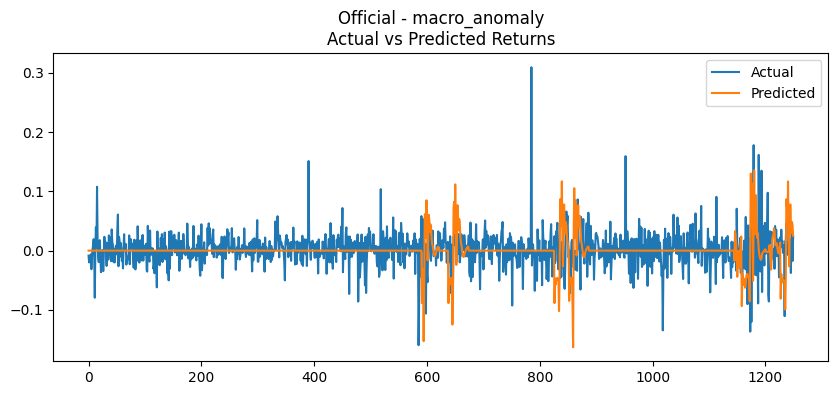

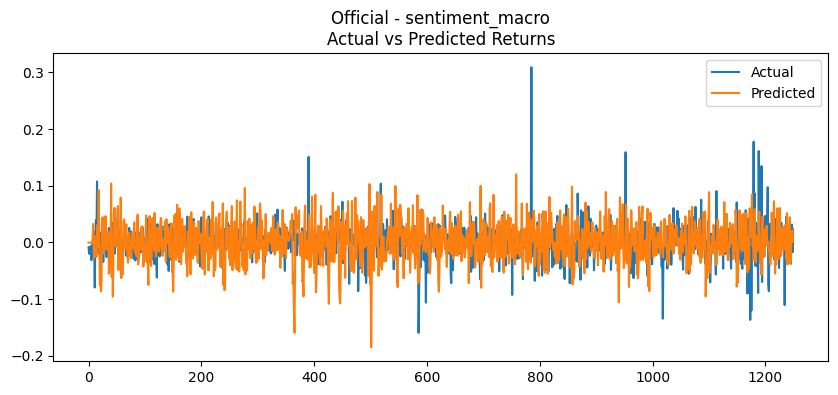

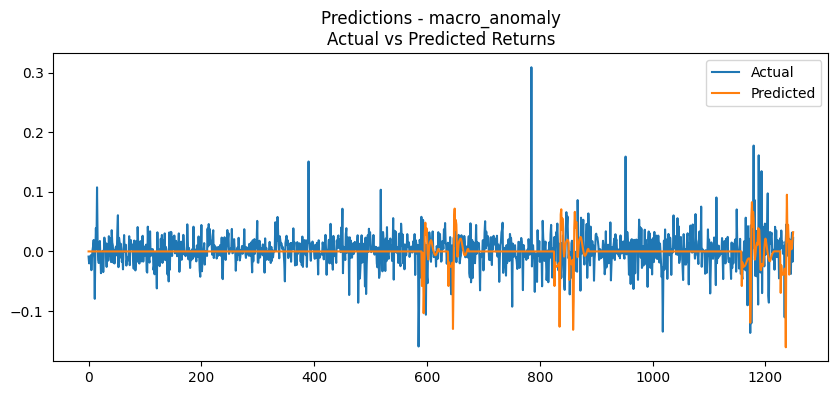

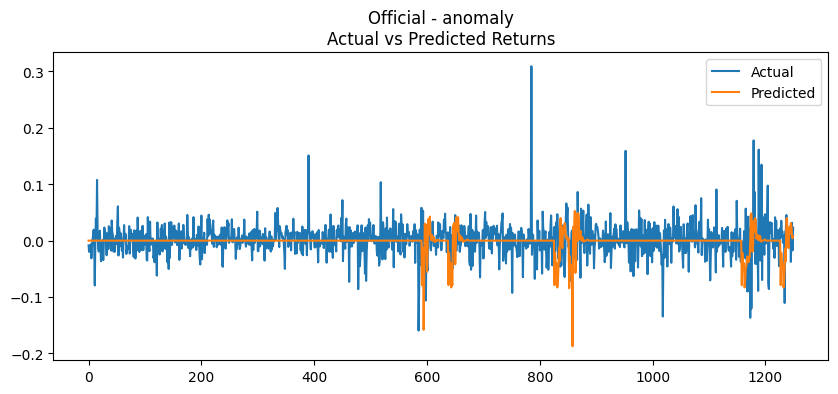

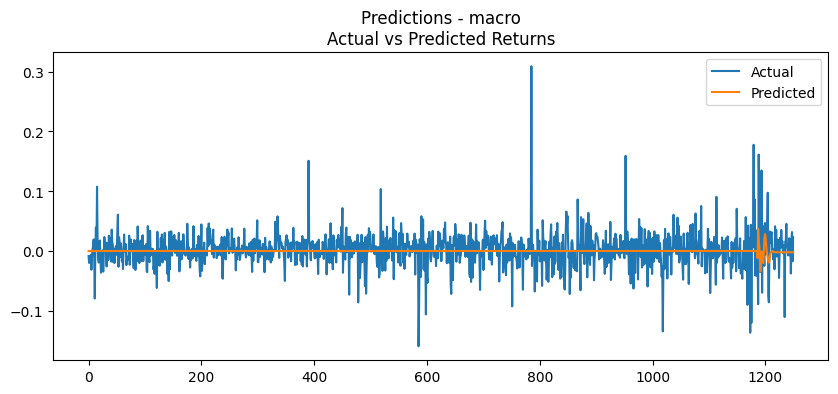

In [30]:
for index, row in top_df.iterrows():
    
    dataset_name = row["dataset"]
    experiment_name = row["experiment"]
    actual = row["actual"]
    predictions = row["predictions"]
    
    title = f"{dataset_name} - {experiment_name}\nActual vs Predicted Returns"
    
    plot_actual_vs_predictions(actual, predictions, title)


## 3.8 Visual Comparison of Top GRU Models vs ARIMA Baseline Return Predictions

This section provides a **visual comparison** of the Top GRU Models with the **ARIMA Baseline Model Return Predictions**.

Below is a screenshot of the **ARIMA Baseline Return Predictions**:
![ARIMA Baseline Returns Predictions Graph](<ARIMA Baseline Screenshots/ARIMA Baseline Returns Predictions Graph.png>)

From the screenshot above we can see that the **ARIMA model predictions are mostly centred around zero**, with very small fluctuations, thich is expected from ARIMA model because it uses only past return values and assumes a linear structure in the data. The result also is also consistent with the **weak form of the Efficient Market Hypothesis [1, Efficient Market Hypothesis: Basics and Forms, 2024]**, which says that historical price information is already reflected in current prices. As a result, models that purely relying on past returns should have limited predictive power and tend to produce predictions close to the mean return.

On the other hand, the **GRU models generate predictions with noticeable spikes** that better follow the magnitude and timing of actual return movements. This shows that incorporating additional information such as sentiment analysis, macreconomic state, and anomaly detection allows the GRU models to better forecast future prices.

Among the five GRU models:
- The **best performing model** is **"Official - macro_anomaly"**, with predictions mostly around zero and spikes appearing from the middle to the end of the graph.
- The **second best** is **"Official - sentiment_macro"**, which also captures some spikes in the returns.
- The **worst performing model** is **"Predictions - macro"**, which is very similar to the ARIMA baseline and shows only small spikes.

Overall, based on visual inspection, the **GRU models** outperform the **ARIMA Baseline** in predicting larger return movements, while some feature combinations work better than others.

> **References:**  
> \[1\] EBC Financial Group, “Efficient Market Hypothesis: Basics and Forms,” 2024-12-19. [Online]. Available: [www.ebc.com](https://www.ebc.com/forex/efficient-market-hypothesis-basics-and-forms)

## 3.9 Plot and Evaluate MSE Bar Charts for GRU Top N Models vs ARIMA Baseline Model

The following code plots **MSE bar charts** comparing the **Top N GRU models** against the **ARIMA baseline** to compare how GRU models using **sentiment analysis**, **anomaly detection**, **and macroeconomic state features** perform relative to the ARIMA model, where **ARIMA represents the weak-form assumption** and the **GRU models represent the semi-strong form** **[1, Efficient Market Hypothesis: Basics and Forms, 2024]** by incorporating additional publicly available information.

> **References:**  
> \[1\] EBC Financial Group, “Efficient Market Hypothesis: Basics and Forms,” 2024-12-19. [Online]. Available: [www.ebc.com](https://www.ebc.com/forex/efficient-market-hypothesis-basics-and-forms)

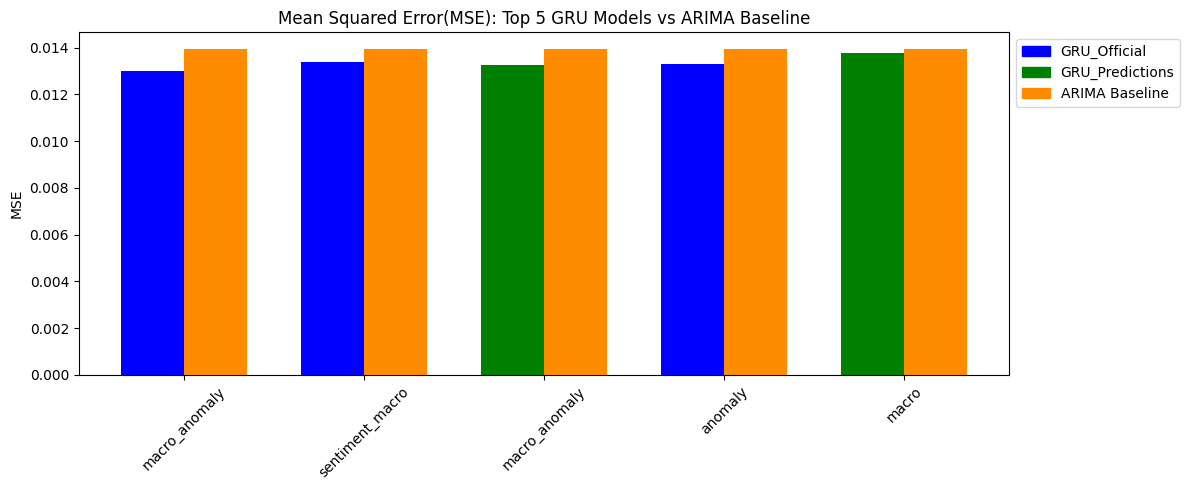

In [31]:
# Call "plot_gru_vs_baseline" function to create bar charts for MSE GRU vs ARIMA comparison
plot_gru_vs_baseline(
    df = top_df,
    metric = "mse",
    baseline_value = baseline_metrics["mse"],
    title = f"Mean Squared Error(MSE): Top {len(top_df)} GRU Models vs ARIMA Baseline",
    ylabel = "MSE",
    legend = gru_vs_arima_legend,
    legend_position = "upper left",
    legend_anchor = (1, 1)
)

From the **MSE bar chart**, we can see that all GRU models performed better than the ARIMA Baseline Model, which had an MSE of 0.013955, achieving lower MSE values. The **best GRU model** is **"Official - macro_anomaly"** with an MSE of 0.013008, using the corresponding dataset and features.

The GRU models **"Official - sentiment_macro"** with an MSE of 0.013375, **"Predictions - macro_anomaly"** with an MSE of 0.013274, and **"Official - anomaly"** with an MSE of 0.013300 produced roughly similar results.

The **"Predictions - macro"** model had the highest MSE among all GRU models with a value of 0.013766.

Overall, the GRU models outperform the ARIMA baseline based on MSE, which confirms the visual observations that some feature combinations produce better results than others.

## 3.10 Plot and Evaluate RMSE Bar Charts for GRU Top N Models vs ARIMA Baseline Model

The following code plots **RMSE bar charts** comparing the **Top N GRU models** against the **ARIMA baseline**, following the same weak-form (ARIMA) versus semi-strong (GRU) comparison framework introduced in Section 3.9.

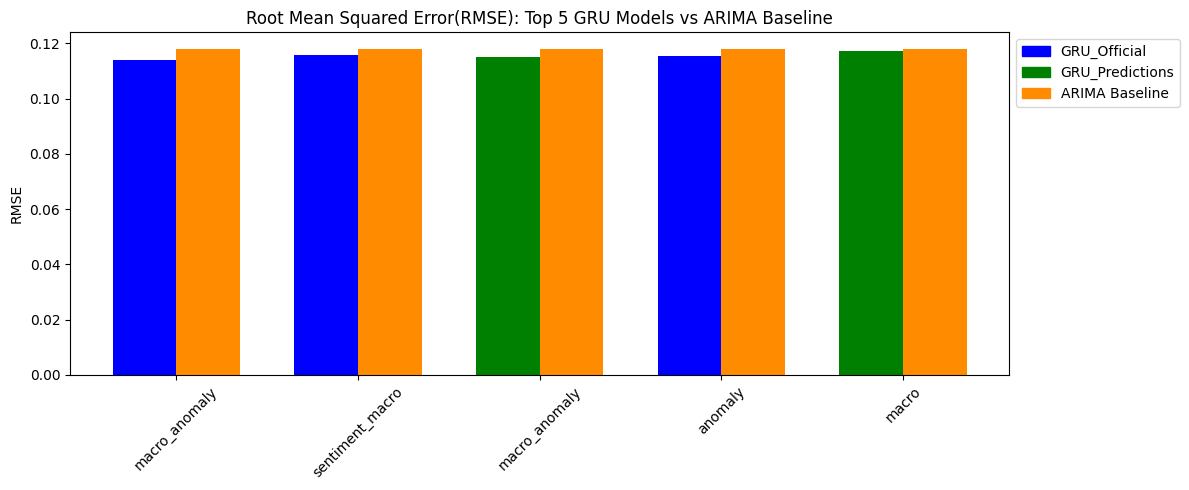

In [32]:
# Call "plot_gru_vs_baseline" function to create bar charts for RMSE GRU vs ARIMA comparison
plot_gru_vs_baseline(
    df = top_df,
    metric = "rmse",
    baseline_value = baseline_metrics["rmse"],
    title = f"Root Mean Squared Error(RMSE): Top {len(top_df)} GRU Models vs ARIMA Baseline",
    ylabel = "RMSE",
    legend = gru_vs_arima_legend,
    legend_position = "upper left",
    legend_anchor = (1, 1)
)

For **RMSE**, the results are very similar to those seen with MSE. The **best GRU model** is **"Official - macro_anomaly"** with an RMSE of 0.114053, while **"Official - sentiment_macro"** with an RMSE of 0.115652, **"Predictions - macro_anomaly"** with an RMSE of 0.115214, and **"Official - anomaly"** with an RMSE of 0.115324 produced roughly similar results.

Applying the square root slightly shifts the **"Predictions - macro"** model closer to the ARIMA baseline, which has an RMSE of 0.118133. However, this GRU model still outperforms the baseline.

Overall, the RMSE results for the GRU models confirm the previous observations, showing that the top GRU models consistently outperform the ARIMA baseline.

## 3.11 Plot and Evaluate MAE Bar Charts for GRU Top N Models vs ARIMA Baseline Model

The following code plots **MAE bar charts** comparing the **Top N GRU models** against the **ARIMA baseline**, following the same weak-form (ARIMA) versus semi-strong (GRU) comparison framework introduced in Section 3.9.

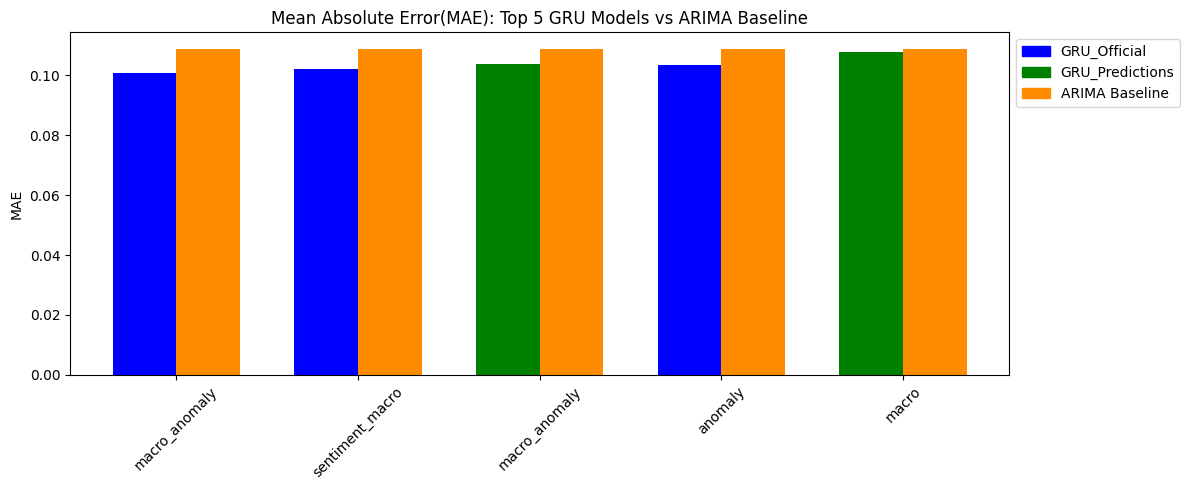

In [33]:
# Call "plot_gru_vs_baseline" function to create bar charts for MAE GRU vs ARIMA comparison
plot_gru_vs_baseline(
    df = top_df,
    metric = "mae",
    baseline_value = baseline_metrics["mae"],
    title = f"Mean Absolute Error(MAE): Top {len(top_df)} GRU Models vs ARIMA Baseline",
    ylabel = "MAE",
    legend = gru_vs_arima_legend,
    legend_position = "upper left",
    legend_anchor = (1, 1)
)

MAE produced very similar results to MSE and RMSE. The **best GRU model** is **"Official - macro_anomaly"** with an MAE of 0.100815, while **"Official - sentiment_macro"** with an MAE of 0.102042, **"Predictions - macro_anomaly"** with an MAE of 0.103913, and **"Official - anomaly"** with an MAE of 0.103390 showed roughly similar performance.

The **"Predictions - macro"** model had the highest MAE among all GRU models at 0.107812, which is close to the ARIMA baseline MAE of 0.108933.

Overall, the MAE results confirm the patterns seen in MSE and RMSE, showing that the top GRU models clearly outperform the ARIMA baseline.

## 3.12 Plot and Evaluate Directional Accuracy Bar Charts for GRU Top N Models vs ARIMA Baseline Model

The following code plots **Directional Accuracy bar charts** comparing the **Top N GRU models** against the **ARIMA baseline**, following the same weak-form (ARIMA) versus semi-strong (GRU) comparison framework introduced in Section 3.9.

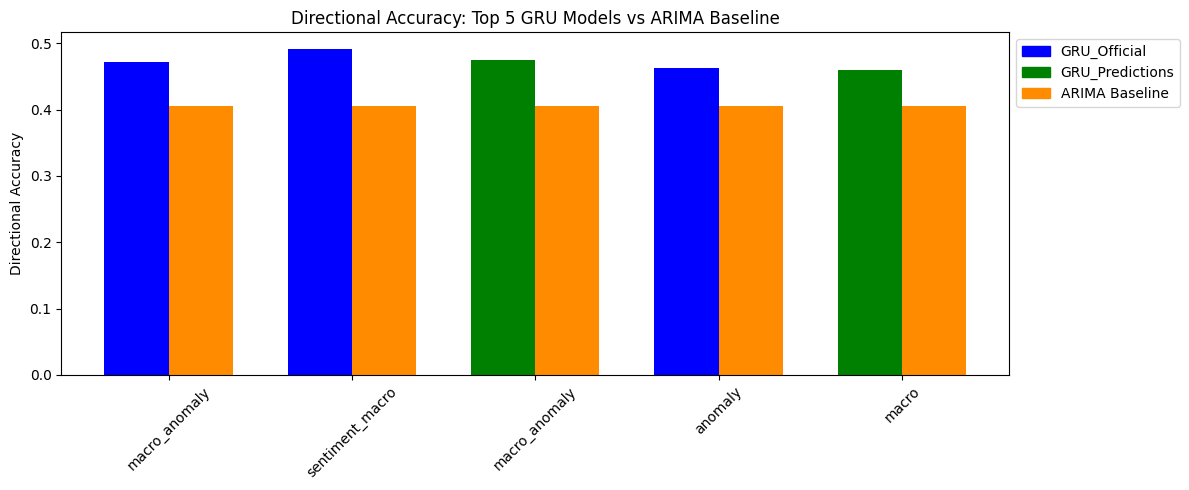

In [34]:
# Call "plot_gru_vs_baseline" function to create bar charts for Directional Accuracy GRU vs ARIMA comparison
plot_gru_vs_baseline(
    df = top_df,
    metric = "directional_accuracy",
    baseline_value = baseline_metrics["directional_accuracy"],
    title = f"Directional Accuracy: Top {len(top_df)} GRU Models vs ARIMA Baseline",
    ylabel = "Directional Accuracy",
    legend = gru_vs_arima_legend,
    legend_position = "upper left",
    legend_anchor = (1, 1)
)

For **Directional Accuracy**, the **best GRU model** is **"Official - sentiment_macro"** with a directional accuracy of 0.4920, followed by **"Predictions - macro_anomaly"** with 0.4744 in second place, and **"Official - macro_anomaly"** with 0.4720 in third. The models **"Official - anomaly"** with 0.4624 and **"Predictions - macro"** with 0.4600 produced similar results, but still achieved higher directional accuracy than the ARIMA baseline of 0.4058.

Overall, the GRU models show higher directional accuracy compared to the ARIMA baseline. However, even the top GRU models only reach about 50% directional accuracy, indicating that they are not making meaningful predictions and are mostly guessing the direction of future returns.

## 3.13 Plot Correlation Bar Charts for GRU Top N Models vs ARIMA Baseline Model

The following code plots **Correlation bar charts** comparing the **Top N GRU models** against the **ARIMA baseline**, following the same weak-form (ARIMA) versus semi-strong (GRU) comparison framework introduced in Section 3.9.

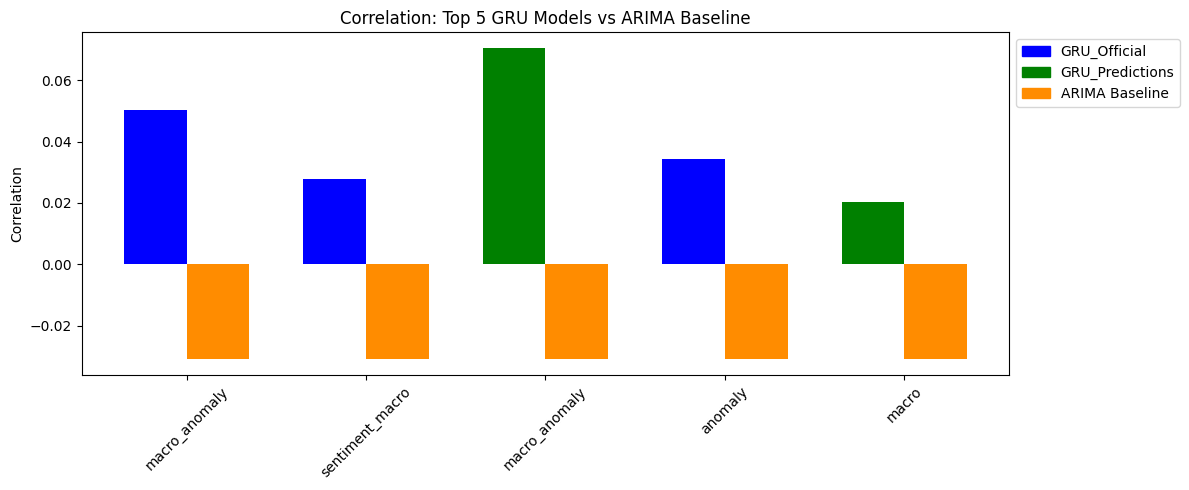

In [35]:
# Call "plot_gru_vs_baseline" function to create bar charts for Correlation GRU vs ARIMA comparison
plot_gru_vs_baseline(
    df = top_df,
    metric = "correlation",
    baseline_value = baseline_metrics["correlation"],
    title = f"Correlation: Top {len(top_df)} GRU Models vs ARIMA Baseline",
    ylabel = "Correlation",
    legend = gru_vs_arima_legend,
    legend_position = "upper left",
    legend_anchor = (1, 1)
)

For **Correlation**, all **Top GRU models** show **positive values**, whereas the **ARIMA baseline** exhibits a **small negative correlation of −0.031**.

The **best-performing GRU model** in terms of correlation is **”Predictions - macro_anomaly”**, achieving the highest correlation of 0.070572 with the actual returns. This is followed by**” Official - macro_anomaly”** with 0.050280 and **”Official - sentiment_macro”** with 0.027956, which also demonstrate modest positive relationships with the return series.

Lower correlation values are observed for **”Official - anomaly”** with 0.034359 and **“Predictions - macro”** with 0.020429, indicating only a weak linear association between predicted and actual returns.
Overall, the **correlation results** suggest that **GRU models capture return direction slightly better than the ARIMA baseline**, but the **correlations remain very small**, confirming that the **return series is largely noisy** and that the **linear relationship between predictions and actual values is weak**.

## 3.14 Plot Improvement Score Bar Charts for GRU Top N Models

The following code creates bar charts to compare the improvement scores of the top N GRU models against the ARIMA baseline:
- **Prepare the legend** for the bar charts:
    - **Blue color** represents **GRU results** on the **official dataset**.
    - **Green color** represents **GRU results** on the **predictions dataset**.
- **Call the plot_gru_vs_baseline() function** to generate the bar chart showing how much each GRU model improved compared to the ARIMA baseline.

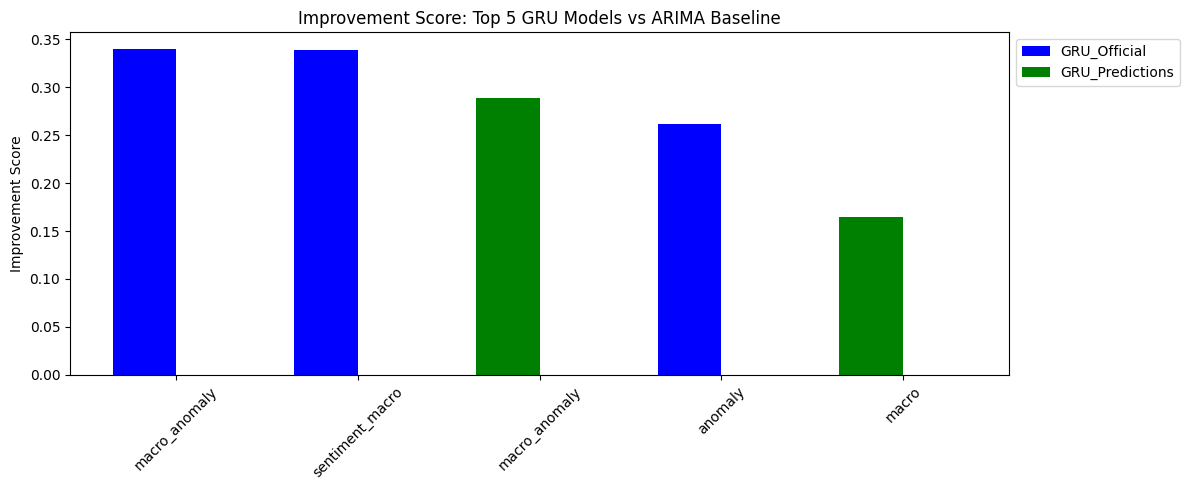

In [36]:
# Legends that are going to be used for comparing improvement score of Top N GRU Model Results to see
# which model performed the best
improvement_score_legend = [
    mpatches.Patch(facecolor='blue', label='GRU_Official'),
    mpatches.Patch(facecolor='green', label='GRU_Predictions')
]

# Call "plot_gru_vs_baseline" function to create bar charts for improvement score 
plot_gru_vs_baseline(
    df = top_df,
    metric = "improvement_score",
    baseline_value = 0,   
    title = f"Improvement Score: Top {len(top_df)} GRU Models vs ARIMA Baseline",
    ylabel = "Improvement Score",
    legend = improvement_score_legend, 
    legend_position = "upper left",
    legend_anchor = (1, 1)
)

From the **Improvement Score bar chart**, we can see how much each of the top GRU models improved compared to the ARIMA baseline. The **best GRU model** is **"Official - macro_anomaly"** with an improvement score of 0.340106, followed closely by **"Official - sentiment_macro"** with 0.338268.

The models **"Predictions - macro_anomaly"** with 0.288668 and **"Official - anomaly"** with 0.261151 produced slightly lower but still significant improvements. The **"Predictions - macro"** model had the lowest improvement score among the top GRU models at 0.164248, but it still outperformed the ARIMA baseline.

Overall, the improvement score confirms that all top GRU models provide better performance than the ARIMA baseline, with certain feature combinations contributing more to the improvement.

---

# 4. Conclusion

The results from this analysis demonstrate that **GRU models incorporating multi-modal financial data** consistently outperform the **ARIMA baseline**, which relies solely on historical returns. Across all evaluation metrics - **MSE, RMSE, MAE, Directional Accuracy, and Correlation** - the top GRU models showed lower error values and slightly higher directional accuracy and correlation compared to ARIMA.

Specifically, the **best-performing model, **”Official – macro_anomaly”**, consistently achieved the **lowest errors** and the **highest improvement score**, highlighting the value of combining **macro-economic state features and anomaly detection signals** with historical returns. Models incorporating **sentiment analysis** also contributed to improved prediction performance, although to a slightly lesser extent.

These findings align with the **Efficient Market Hypothesis**: the **ARIMA baseline reflects the weak-form EMH**, which assumes that historical price information alone is already incorporated into current prices, resulting in limited predictive power. In contrast, the **GRU models represent the semi-strong form of EMH** by leveraging additional publicly available information such as sentiment, macroeconomic states, and anomaly signals, which provides measurable predictive advantages.

However, even the top GRU models achieved **directional accuracy of only around 50%** and **low correlations with actual returns**, indicating that **financial returns remain largely noisy and difficult to predict**. This suggests that while multi-modal GRU models provide some improvement over linear baselines, predicting short-term price movements remains challenging.

Overall, the notebook demonstrates that **deep learning models like GRU can extract meaningful patterns from additional market information**, offering better forecasting performance than traditional linear models, but the inherent unpredictability of financial markets still limits the achievable accuracy. These insights provide practical guidance for applying machine learning in **financial time series forecasting**, especially when combining historical and external data sources.